# PHQ-9, Anxiety, and Psychomotor Response Analysis

This notebook focuses on the main hypothesis that depressive symptoms, especially anhedonia and reduced motivation, are associated with a stunted psychomotor response.

Primary outcome: `std_dev_y`
Secondary outcome: `rot_speed_avg_total`
Main predictor: `score_phq`
Key covariate for overlap with depression: `score_gad`

The analysis is exploratory, so the main goal is to understand the pattern carefully, not to force a single dichotomous conclusion.

In [13]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import shapiro, chi2
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import OLSInfluence, variance_inflation_factor

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

DATA_FILE = r'd:\25-26_Spring\Behavioural Research SM\codes\360 Videos VR project\final_long_format.csv'
OUTPUT_DIR = r'd:\25-26_Spring\Behavioural Research SM\codes\360 Videos VR project\visualizations\regression_outputs\final_sy'
os.makedirs(OUTPUT_DIR, exist_ok=True)

df = pd.read_csv(DATA_FILE)
df = df.rename(columns={
    'SD_y': 'std_dev_y',
    'RS_mean': 'rot_speed_avg_total'
})
df['video'] = pd.Categorical(df['video'], categories=['v1', 'v2', 'v3', 'v4', 'v5'], ordered=True)
df['vr_experience'] = df['vr_experience'].astype('category')

print('Loaded simplified long-format data')
print(f'Rows: {len(df)}')
print(f'Participants: {df["participant_id"].nunique()}')
print(f'Videos: {df["video"].nunique()}')
display(df.head())

Loaded simplified long-format data
Rows: 200
Participants: 40
Videos: 5


,participant_id,CA_y,CA_z,SD_x,std_dev_y,SD_z,RS_x,RS_y,RS_z,rot_speed_avg_total,video,score_phq,score_gad,score_stai_t,vr_experience,valence,arousal
0,1,28.059970,-5.042306,9.718494,139.41260,1.473306,11.030340,27.88603,5.021842,33.56095,v1,13,5,49,2,4,4
1,2,7.037723,3.757108,1.697871,10.69260,5.348539,16.629130,35.30318,8.344629,44.25587,v1,1,1,35,1,4,5
2,3,2.157359,-5.837924,43.983510,25.04630,6.419613,17.441710,37.66362,11.230990,47.41575,v1,5,6,46,1,5,3
3,4,32.759830,-0.818684,16.064810,24.80434,4.213634,14.882940,34.72771,16.101620,47.45705,v1,0,0,25,2,7,8
4,5,7.410412,3.989732,39.002100,14.88157,0.523874,9.647408,22.76349,5.356993,28.67677,v1,12,8,48,1,5,5


## Variable Roles and Hypothesis

The hypothesis is that depression should be associated with reduced psychomotor response. In this dataset, that means testing whether higher PHQ-9 scores predict lower movement variability or speed outcomes.

Because anxiety and depression are correlated, GAD-7 is included as a covariate in the adjusted models so the PHQ effect can be interpreted more cleanly.

In [14]:
variable_roles = pd.DataFrame([
    {'variable': 'participant_id', 'role': 'participant identifier', 'type': 'categorical', 'scale': 'nominal'},
    {'variable': 'video', 'role': 'repeated-measures factor', 'type': 'categorical', 'scale': 'nominal'},
    {'variable': 'score_phq', 'role': 'main predictor', 'type': 'score', 'scale': 'ordinal score treated as continuous'},
    {'variable': 'score_gad', 'role': 'covariate for overlap', 'type': 'score', 'scale': 'ordinal score treated as continuous'},
    {'variable': 'score_stai_t', 'role': 'exploratory covariate', 'type': 'score', 'scale': 'ordinal score treated as continuous'},
    {'variable': 'vr_experience', 'role': 'covariate', 'type': 'categorical', 'scale': 'ordinal-coded categorical'},
    {'variable': 'valence', 'role': 'exploratory covariate', 'type': 'numeric', 'scale': 'rating scale'},
    {'variable': 'arousal', 'role': 'exploratory covariate', 'type': 'numeric', 'scale': 'rating scale'},
    {'variable': 'std_dev_y', 'role': 'main outcome', 'type': 'numeric', 'scale': 'continuous'},
    {'variable': 'rot_speed_avg_total', 'role': 'secondary outcome', 'type': 'numeric', 'scale': 'continuous'}
])
display(variable_roles)

,variable,role,type,scale
0,participant_id,participant identifier,categorical,nominal
1,video,repeated-measures factor,categorical,nominal
2,score_phq,main predictor,score,ordinal score treated as continuous
3,score_gad,covariate for overlap,score,ordinal score treated as continuous
4,score_stai_t,exploratory covariate,score,ordinal score treated as continuous
5,vr_experience,covariate,categorical,ordinal-coded categorical
6,valence,exploratory covariate,numeric,rating scale
7,arousal,exploratory covariate,numeric,rating scale
8,std_dev_y,main outcome,numeric,continuous
9,rot_speed_avg_total,secondary outcome,numeric,continuous


In [15]:
print('Descriptive summary:')
display(df.describe(include='all').transpose())

missing = df.isna().sum().sort_values(ascending=False)
print('Missing values:')
print(missing[missing > 0].to_string() if (missing > 0).any() else 'No missing values')

Descriptive summary:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
participant_id,200.0,NaN,NaN,NaN,20.5,11.572364,1.0,10.75,20.5,30.25,40.0
CA_y,200.0,NaN,NaN,NaN,7.265549,24.204641,-66.19716,-5.507628,4.602108,21.31247,68.66
CA_z,200.0,NaN,NaN,NaN,-1.221004,2.483002,-7.864152,-2.722101,-1.202203,0.349727,5.768587
SD_x,200.0,NaN,NaN,NaN,22.163673,15.425341,0.13209,10.879442,20.00424,30.125143,86.30961
std_dev_y,200.0,NaN,NaN,NaN,59.417803,53.512448,0.309049,13.65351,42.10621,99.709023,179.9029
SD_z,200.0,NaN,NaN,NaN,3.046969,2.781026,0.033083,1.019714,2.322754,4.196325,15.26683
RS_x,200.0,NaN,NaN,NaN,10.191718,4.411278,2.083113,6.910674,9.63526,12.55857,26.07208
RS_y,200.0,NaN,NaN,NaN,26.5842,9.880834,4.518692,21.355345,26.720555,33.913585,48.6866
RS_z,200.0,NaN,NaN,NaN,5.671281,2.553435,1.279962,3.828139,5.256265,6.998348,16.10162
rot_speed_avg_total,200.0,NaN,NaN,NaN,32.381358,11.577749,5.921618,25.583842,32.472335,40.796035,57.12766


Missing values:
No missing values


## PHQ-GAD Overlap and Correlation Exploration

Before interpreting PHQ as the depression signal, it is important to see how strongly PHQ and GAD move together and whether the outcome relationships look plausible in the raw data.

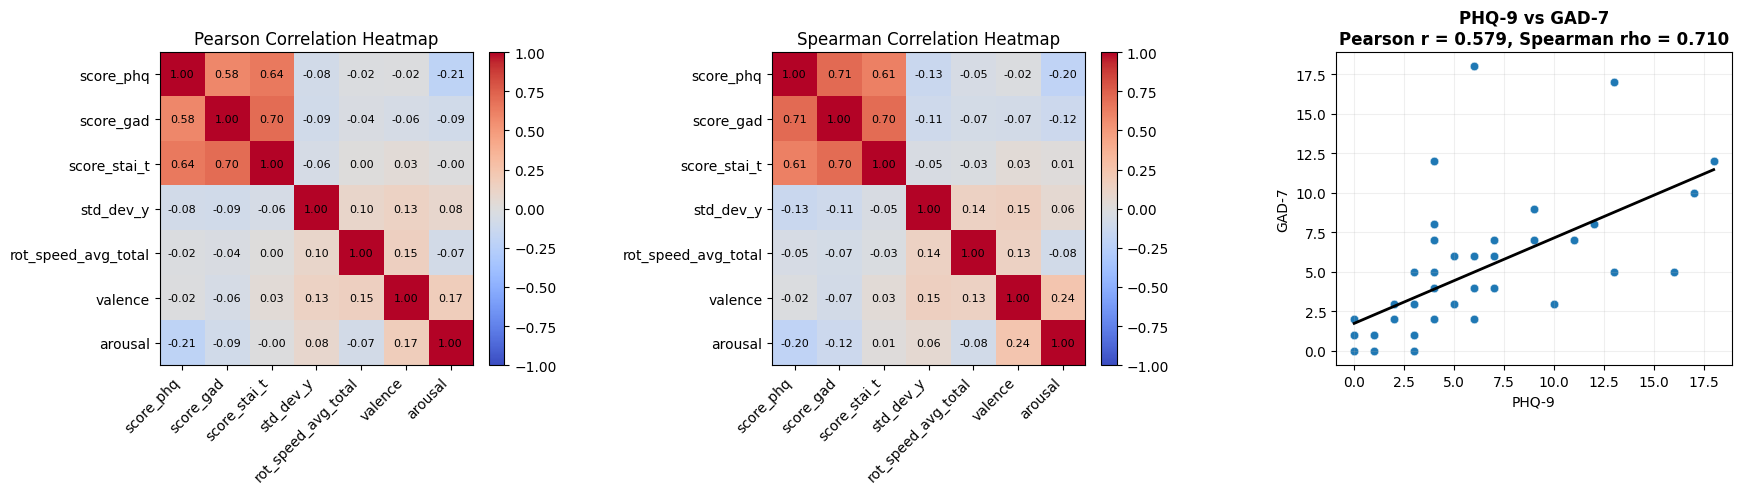

Saved: d:\25-26_Spring\Behavioural Research SM\codes\360 Videos VR project\visualizations\regression_outputs\final_sy\phq_gad_correlation_pearson_spearman.png
PHQ-GAD Pearson r: 0.579
PHQ-GAD Spearman rho: 0.710


,var_x,var_y,pearson_r,spearman_rho
6,score_gad,score_stai_t,0.696717,0.701051
1,score_phq,score_stai_t,0.642466,0.612994
0,score_phq,score_gad,0.579257,0.710251
5,score_phq,arousal,-0.207388,-0.197299
20,valence,arousal,0.174148,0.238319
18,rot_speed_avg_total,valence,0.151971,0.133657
16,std_dev_y,valence,0.132067,0.150556
15,std_dev_y,rot_speed_avg_total,0.095554,0.135588
10,score_gad,arousal,-0.090503,-0.122279
7,score_gad,std_dev_y,-0.087313,-0.108942


Saved: d:\25-26_Spring\Behavioural Research SM\codes\360 Videos VR project\visualizations\regression_outputs\final_sy\correlation_pairs_pearson_spearman.csv


In [16]:
corr_vars = ['score_phq', 'score_gad', 'score_stai_t', 'std_dev_y', 'rot_speed_avg_total', 'valence', 'arousal']
corr_df = df[corr_vars].copy()

pearson_corr = corr_df.corr(method='pearson', numeric_only=True)
spearman_corr = corr_df.corr(method='spearman', numeric_only=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

im1 = axes[0].imshow(pearson_corr, cmap='coolwarm', vmin=-1, vmax=1)
axes[0].set_xticks(range(len(corr_vars)))
axes[0].set_yticks(range(len(corr_vars)))
axes[0].set_xticklabels(corr_vars, rotation=45, ha='right')
axes[0].set_yticklabels(corr_vars)
axes[0].set_title('Pearson Correlation Heatmap')
for i in range(len(corr_vars)):
    for j in range(len(corr_vars)):
        axes[0].text(j, i, f'{pearson_corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=8)

im2 = axes[1].imshow(spearman_corr, cmap='coolwarm', vmin=-1, vmax=1)
axes[1].set_xticks(range(len(corr_vars)))
axes[1].set_yticks(range(len(corr_vars)))
axes[1].set_xticklabels(corr_vars, rotation=45, ha='right')
axes[1].set_yticklabels(corr_vars)
axes[1].set_title('Spearman Correlation Heatmap')
for i in range(len(corr_vars)):
    for j in range(len(corr_vars)):
        axes[1].text(j, i, f'{spearman_corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=8)

plot_df = df[['score_phq', 'score_gad']].dropna().copy()
axes[2].scatter(plot_df['score_phq'], plot_df['score_gad'], s=38, alpha=0.75, color='#1F78B4', edgecolor='white', linewidth=0.5)
if len(plot_df) >= 2:
    slope, intercept = np.polyfit(plot_df['score_phq'], plot_df['score_gad'], 1)
    xs = np.linspace(plot_df['score_phq'].min(), plot_df['score_phq'].max(), 100)
    axes[2].plot(xs, slope * xs + intercept, color='black', linewidth=2)

r_pearson_pg = plot_df['score_phq'].corr(plot_df['score_gad'], method='pearson')
r_spearman_pg = plot_df['score_phq'].corr(plot_df['score_gad'], method='spearman')
axes[2].set_title(f'PHQ-9 vs GAD-7\nPearson r = {r_pearson_pg:.3f}, Spearman rho = {r_spearman_pg:.3f}', weight='bold')
axes[2].set_xlabel('PHQ-9')
axes[2].set_ylabel('GAD-7')
axes[2].grid(alpha=0.2)

fig.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)
fig.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
corr_path = os.path.join(OUTPUT_DIR, 'phq_gad_correlation_pearson_spearman.png')
plt.savefig(corr_path, dpi=300, bbox_inches='tight')
plt.show()

print(f'Saved: {corr_path}')
print(f'PHQ-GAD Pearson r: {r_pearson_pg:.3f}')
print(f'PHQ-GAD Spearman rho: {r_spearman_pg:.3f}')

# Compact table for report text.
pair_rows = []
for x in corr_vars:
    for y in corr_vars:
        if corr_vars.index(y) <= corr_vars.index(x):
            continue
        pair_rows.append({
            'var_x': x,
            'var_y': y,
            'pearson_r': corr_df[x].corr(corr_df[y], method='pearson'),
            'spearman_rho': corr_df[x].corr(corr_df[y], method='spearman')
        })

corr_pairs_df = pd.DataFrame(pair_rows)
display(corr_pairs_df.sort_values(by='pearson_r', key=lambda s: s.abs(), ascending=False).head(12))

corr_pairs_path = os.path.join(OUTPUT_DIR, 'correlation_pairs_pearson_spearman.csv')
corr_pairs_df.to_csv(corr_pairs_path, index=False)
print(f'Saved: {corr_pairs_path}')

## Participant Partitioning for the Hypothesis

For interpretation, participants are grouped using standard PHQ-9 severity bands. This is better than an arbitrary median split because it preserves a clinically meaningful interpretation.

Primary inference remains continuous PHQ-9 in regression. The groups are mainly for plotting and explanatory comparison.

In [17]:
def fit_mixed_with_fallback(data, formula_candidates):
    fit_errors_local = []
    for formula in formula_candidates:
        for method in ['lbfgs', 'powell', 'cg']:
            try:
                model = smf.mixedlm(formula, data=data, groups=data['participant_id'])
                result = model.fit(reml=False, method=method, maxiter=200)
                if np.isfinite(result.llf):
                    return result, formula, method, fit_errors_local
            except Exception as e:
                fit_errors_local.append(f'{formula} [{method}] -> {e}')
    return None, None, None, fit_errors_local

formula_candidates = [
    'std_dev_y ~ score_phq + C(video) + score_gad + score_stai_t + valence + arousal',
    'std_dev_y ~ score_phq + C(video) + score_gad + score_stai_t',
    'std_dev_y ~ score_phq + C(video) + score_gad',
    'std_dev_y ~ score_phq + C(video)'
]

mixed_full, mixed_formula_used, mixed_method, mixed_errors = fit_mixed_with_fallback(df_mixed, formula_candidates)
if mixed_full is None:
    print('Mixed model failed to converge. Last errors:')
    print('\n'.join(mixed_errors[-5:]))
    raise RuntimeError('Mixed model failed.')

print('Mixed model used:')
print(mixed_formula_used)
print(f'Fit method: {mixed_method}')
print(mixed_full.summary())

phq_beta = float(mixed_full.params.get('score_phq', np.nan))
phq_se = float(mixed_full.bse.get('score_phq', np.nan))
phq_p = float(mixed_full.pvalues.get('score_phq', np.nan))
phq_ci_low = phq_beta - 1.96 * phq_se
phq_ci_high = phq_beta + 1.96 * phq_se

gad_beta = float(mixed_full.params.get('score_gad', np.nan))
gad_se = float(mixed_full.bse.get('score_gad', np.nan))
gad_p = float(mixed_full.pvalues.get('score_gad', np.nan))
gad_ci_low = gad_beta - 1.96 * gad_se
gad_ci_high = gad_beta + 1.96 * gad_se

print('Key adjusted estimates:')
print(f'PHQ-9 beta={phq_beta:.4f}, p={phq_p:.4f}, 95% CI=[{phq_ci_low:.4f}, {phq_ci_high:.4f}]')
print(f'GAD-7 beta={gad_beta:.4f}, p={gad_p:.4f}, 95% CI=[{gad_ci_low:.4f}, {gad_ci_high:.4f}]')

mixed_table = pd.DataFrame({
    'term': mixed_full.params.index,
    'beta': mixed_full.params.values,
    'std_error': mixed_full.bse.values,
    'p_value': mixed_full.pvalues.values,
    'ci_low': mixed_full.params.values - 1.96 * mixed_full.bse.values,
    'ci_high': mixed_full.params.values + 1.96 * mixed_full.bse.values
})
display(mixed_table)

mixed_path = os.path.join(OUTPUT_DIR, 'mixed_model_coefficients.csv')
mixed_table.to_csv(mixed_path, index=False)
print(f'Saved: {mixed_path}')

Mixed model used:
std_dev_y ~ score_phq + C(video) + score_gad + score_stai_t + valence + arousal
Fit method: powell
           Mixed Linear Model Regression Results
Model:              MixedLM  Dependent Variable:  std_dev_y 
No. Observations:   200      Method:              ML        
No. Groups:         40       Scale:               2224.9990 
Min. group size:    5        Log-Likelihood:      -1054.5389
Max. group size:    5        Converged:           Yes       
Mean group size:    5.0                                     
------------------------------------------------------------
                Coef.  Std.Err.   z    P>|z|  [0.025  0.975]
------------------------------------------------------------
Intercept       69.998   17.325  4.040 0.000  36.040 103.955
C(video)[T.v2]  20.911   10.888  1.921 0.055  -0.430  42.251
C(video)[T.v3]  17.169   10.761  1.595 0.111  -3.923  38.261
C(video)[T.v4] -48.020   11.455 -4.192 0.000 -70.471 -25.569
C(video)[T.v5]  36.481   11.518  3.167 0.

,term,beta,std_error,p_value,ci_low,ci_high
0,Intercept,6.999773e+01,17.325451,0.000053,36.039843,103.955610
1,C(video)[T.v2],2.091089e+01,10.888169,0.054793,-0.429924,42.251700
2,C(video)[T.v3],1.716921e+01,10.761439,0.110614,-3.923207,38.261635
3,C(video)[T.v4],-4.802026e+01,11.454749,0.000028,-70.471570,-25.568952
4,C(video)[T.v5],3.648083e+01,11.517824,0.001538,13.905900,59.055769
5,score_phq,-2.695541e-01,1.020679,0.791708,-2.270084,1.730976
6,score_gad,-1.211152e+00,1.134037,0.285520,-3.433864,1.011561
7,score_stai_t,1.211989e-01,0.360945,0.737035,-0.586253,0.828651
8,valence,-5.409498e+00,2.055308,0.008489,-9.437902,-1.381094
9,arousal,3.335502e+00,1.862961,0.073385,-0.315901,6.986905


Saved: d:\25-26_Spring\Behavioural Research SM\codes\360 Videos VR project\visualizations\regression_outputs\final_sy\mixed_model_coefficients.csv


## Main Predictor Sufficiency Check

Before interpreting interactions, check whether PHQ-9 and GAD-7 each work on their own, and whether the combined model adds anything beyond either single predictor.

This answers the logical follow-up question: if the PHQ+GAD model is useful, is one predictor alone enough, or do we need both?

In [18]:
# Compare PHQ-only, GAD-only, and PHQ+GAD models on the primary outcome.
score_phq_c = df_mixed['score_phq'] - df_mixed['score_phq'].mean()
score_gad_c = df_mixed['score_gad'] - df_mixed['score_gad'].mean()
score_stai_t_c = df_mixed['score_stai_t'] - df_mixed['score_stai_t'].mean()

sufficiency_specs = [
    ('PHQ only', 'std_dev_y ~ score_phq_c + score_stai_t_c + C(video) + C(vr_experience)'),
    ('GAD only', 'std_dev_y ~ score_gad_c + score_stai_t_c + C(video) + C(vr_experience)'),
    ('PHQ + GAD', 'std_dev_y ~ score_phq_c + score_gad_c + score_stai_t_c + C(video) + C(vr_experience)')
]

sufficiency_rows = []
sufficiency_results = {}

for label, formula in sufficiency_specs:
    result, used_formula, fit_method, _ = fit_mixed_with_fallback(df_mixed, [formula])
    sufficiency_results[label] = result
    if result is None:
        sufficiency_rows.append({
            'model': label,
            'formula': formula,
            'fit_method': None,
            'aic': np.nan,
            'phq_beta': np.nan,
            'phq_p': np.nan,
            'gad_beta': np.nan,
            'gad_p': np.nan
        })
        continue
    sufficiency_rows.append({
        'model': label,
        'formula': used_formula,
        'fit_method': fit_method,
        'aic': result.aic,
        'phq_beta': float(result.params.get('score_phq_c', np.nan)) if 'score_phq_c' in result.params.index else np.nan,
        'phq_p': float(result.pvalues.get('score_phq_c', np.nan)) if 'score_phq_c' in result.pvalues.index else np.nan,
        'gad_beta': float(result.params.get('score_gad_c', np.nan)) if 'score_gad_c' in result.params.index else np.nan,
        'gad_p': float(result.pvalues.get('score_gad_c', np.nan)) if 'score_gad_c' in result.pvalues.index else np.nan
    })

sufficiency_df = pd.DataFrame(sufficiency_rows)
display(sufficiency_df)

phq_only = sufficiency_results.get('PHQ only')
gad_only = sufficiency_results.get('GAD only')
phq_gad = sufficiency_results.get('PHQ + GAD')

if phq_only is not None and phq_gad is not None:
    phq_lrt = 2 * (phq_gad.llf - phq_only.llf)
    phq_df = int(phq_gad.df_modelwc - phq_only.df_modelwc)
    phq_p_add = chi2.sf(phq_lrt, phq_df) if phq_df > 0 else np.nan
    print(f'PHQ added to GAD-only model: LRT p = {phq_p_add:.4f}')

if gad_only is not None and phq_gad is not None:
    gad_lrt = 2 * (phq_gad.llf - gad_only.llf)
    gad_df = int(phq_gad.df_modelwc - gad_only.df_modelwc)
    gad_p_add = chi2.sf(gad_lrt, gad_df) if gad_df > 0 else np.nan
    print(f'GAD added to PHQ-only model: LRT p = {gad_p_add:.4f}')

if phq_only is not None and gad_only is not None and phq_gad is not None:
    print('Interpretation rule: if both addition tests are significant, neither predictor is sufficient alone; the combined model is justified.')


,model,formula,fit_method,aic,phq_beta,phq_p,gad_beta,gad_p
0,PHQ only,std_dev_y ~ score_phq_c + score_stai_t_c + C(v...,powell,2138.061153,-0.905330,0.355113,NaN,NaN
1,GAD only,std_dev_y ~ score_gad_c + score_stai_t_c + C(v...,powell,2137.862079,NaN,NaN,-1.170995,0.304329
2,PHQ + GAD,std_dev_y ~ score_phq_c + score_gad_c + score_...,powell,2139.354203,-0.715287,0.475780,-0.983388,0.400042


PHQ added to GAD-only model: LRT p = 0.4005
GAD added to PHQ-only model: LRT p = 0.4761
Interpretation rule: if both addition tests are significant, neither predictor is sufficient alone; the combined model is justified.


## Mixed Model Plots

These figures show the mixed-regression results more directly: one plot compares the standalone PHQ and GAD models against the combined model, and the other shows the PHQ × GAD moderation pattern.

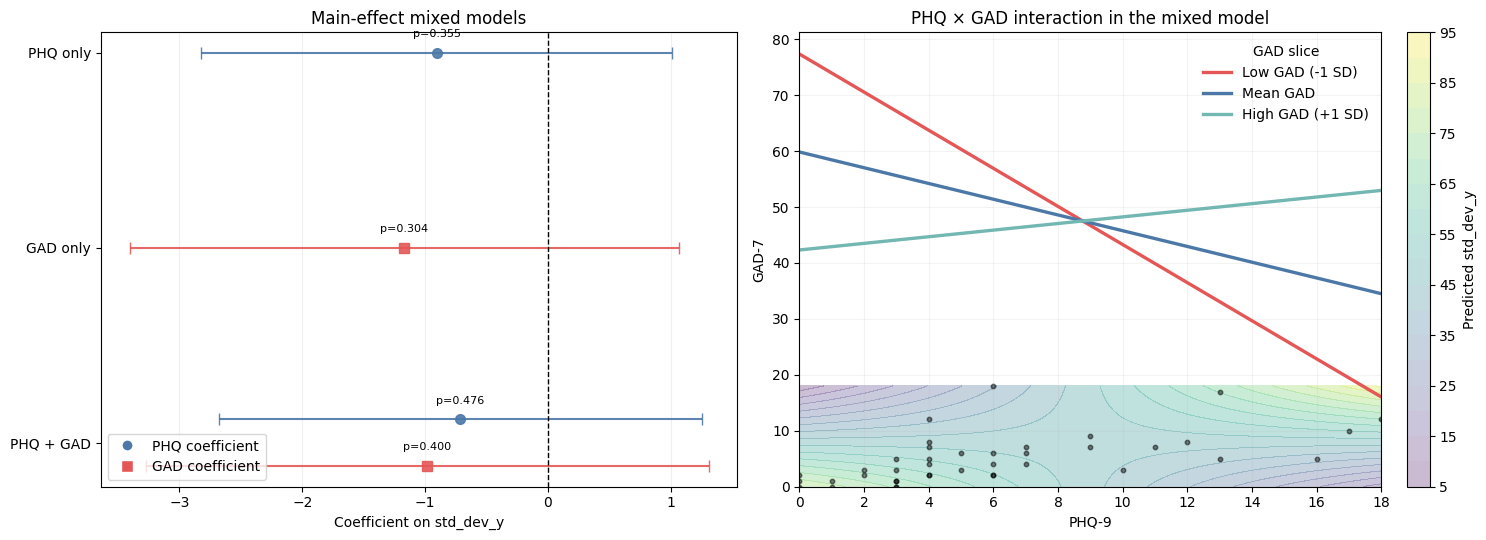

Saved: d:\25-26_Spring\Behavioural Research SM\codes\360 Videos VR project\visualizations\regression_outputs\final_sy\mixed_model_main_and_interaction_plots.png


In [19]:
# Visualize the main-effects models and the PHQ x GAD interaction from the mixed regression.
from matplotlib.lines import Line2D

# Refit the interaction model used for the moderation plot.
phq_gad_interaction, phq_gad_interaction_formula, phq_gad_interaction_method, _ = fit_mixed_with_fallback(
    df_mixed,
    ['std_dev_y ~ score_phq_c * score_gad_c + score_stai_t_c + C(video) + C(vr_experience)']
)

if phq_gad_interaction is None:
    raise RuntimeError('PHQ x GAD interaction model did not converge.')

phq_grid = np.linspace(df_mixed['score_phq'].min(), df_mixed['score_phq'].max(), 80)
gad_grid = np.linspace(df_mixed['score_gad'].min(), df_mixed['score_gad'].max(), 80)
phq_mean = df_mixed['score_phq'].mean()
gad_mean = df_mixed['score_gad'].mean()
gad_sd = df_mixed['score_gad'].std()
score_stai_mean = df_mixed['score_stai_t'].mean()
video_ref = df_mixed['video'].mode().iloc[0]
vr_ref = df_mixed['vr_experience'].astype('category').cat.categories[0]

def predict_interaction(phq_values, gad_value, vr_value):
    frame = pd.DataFrame({
        'score_phq_c': phq_values - phq_mean,
        'score_gad_c': gad_value - gad_mean,
        'score_stai_t_c': 0,
        'video': video_ref,
        'vr_experience': vr_value,
    })
    return phq_gad_interaction.predict(frame)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# Panel 1: main-effects coefficient comparison.
coef_rows = [
    {'model': 'PHQ only', 'term': 'PHQ', 'beta': phq_only.params.get('score_phq_c', np.nan), 'se': phq_only.bse.get('score_phq_c', np.nan), 'p': phq_only.pvalues.get('score_phq_c', np.nan)},
    {'model': 'GAD only', 'term': 'GAD', 'beta': gad_only.params.get('score_gad_c', np.nan), 'se': gad_only.bse.get('score_gad_c', np.nan), 'p': gad_only.pvalues.get('score_gad_c', np.nan)},
    {'model': 'PHQ + GAD', 'term': 'PHQ', 'beta': phq_gad.params.get('score_phq_c', np.nan), 'se': phq_gad.bse.get('score_phq_c', np.nan), 'p': phq_gad.pvalues.get('score_phq_c', np.nan)},
    {'model': 'PHQ + GAD', 'term': 'GAD', 'beta': phq_gad.params.get('score_gad_c', np.nan), 'se': phq_gad.bse.get('score_gad_c', np.nan), 'p': phq_gad.pvalues.get('score_gad_c', np.nan)},
]

coef_df = pd.DataFrame(coef_rows)
y_positions = {'PHQ only': 3, 'GAD only': 2, 'PHQ + GAD': 1}
markers = {'PHQ': 'o', 'GAD': 's'}
colors = {'PHQ': '#4C78A8', 'GAD': '#E45756'}

for _, row in coef_df.iterrows():
    y = y_positions[row['model']] + (0.12 if row['term'] == 'PHQ' and row['model'] == 'PHQ + GAD' else -0.12 if row['term'] == 'GAD' and row['model'] == 'PHQ + GAD' else 0)
    axes[0].errorbar(row['beta'], y, xerr=1.96 * row['se'], fmt=markers[row['term']], color=colors[row['term']], capsize=4, markersize=7, alpha=0.9)
    axes[0].text(row['beta'], y + 0.08, f"p={row['p']:.3f}", fontsize=8, ha='center')

axes[0].axvline(0, color='black', linestyle='--', linewidth=1)
axes[0].set_yticks([1, 2, 3])
axes[0].set_yticklabels(['PHQ + GAD', 'GAD only', 'PHQ only'])
axes[0].set_title('Main-effect mixed models')
axes[0].set_xlabel('Coefficient on std_dev_y')
axes[0].grid(alpha=0.2, axis='x')
axes[0].legend(handles=[
    Line2D([0], [0], marker='o', color='w', label='PHQ coefficient', markerfacecolor=colors['PHQ'], markersize=8),
    Line2D([0], [0], marker='s', color='w', label='GAD coefficient', markerfacecolor=colors['GAD'], markersize=8),
], loc='lower left')

# Panel 2: PHQ x GAD interaction as simple slopes and a predicted surface slice.
for gad_value, label, color in [(gad_mean - gad_sd, 'Low GAD (-1 SD)', '#E45756'), (gad_mean, 'Mean GAD', '#4C78A8'), (gad_mean + gad_sd, 'High GAD (+1 SD)', '#72B7B2')]:
    axes[1].plot(phq_grid, predict_interaction(phq_grid, gad_value, vr_ref), color=color, linewidth=2.4, label=label)

phq_gad_surface = np.zeros((len(gad_grid), len(phq_grid)))
for i, gad_value in enumerate(gad_grid):
    phq_gad_surface[i, :] = predict_interaction(phq_grid, gad_value, vr_ref)

contour = axes[1].contourf(phq_grid, gad_grid, phq_gad_surface, levels=20, cmap='viridis', alpha=0.28)
axes[1].scatter(df_mixed['score_phq'], df_mixed['score_gad'], s=10, alpha=0.12, color='black')
axes[1].set_title('PHQ × GAD interaction in the mixed model')
axes[1].set_xlabel('PHQ-9')
axes[1].set_ylabel('GAD-7')
axes[1].legend(title='GAD slice', frameon=False)
axes[1].grid(alpha=0.15)
cbar = plt.colorbar(contour, ax=axes[1], fraction=0.046, pad=0.04)
cbar.set_label('Predicted std_dev_y')

plt.tight_layout()
mixed_plot_path = os.path.join(OUTPUT_DIR, 'mixed_model_main_and_interaction_plots.png')
plt.savefig(mixed_plot_path, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved: {mixed_plot_path}')

In [20]:
# Mean-center the continuous predictors used in moderation tests.
df_mixed['score_phq_c'] = df_mixed['score_phq'] - df_mixed['score_phq'].mean()
df_mixed['score_gad_c'] = df_mixed['score_gad'] - df_mixed['score_gad'].mean()
df_mixed['score_stai_t_c'] = df_mixed['score_stai_t'] - df_mixed['score_stai_t'].mean()

interaction_specs = [
    {
        'label': 'Base main-effects model',
        'formula': 'std_dev_y ~ score_phq_c + score_gad_c + score_stai_t_c + C(video) + C(vr_experience)'
    },
    {
        'label': 'PHQ x GAD',
        'formula': 'std_dev_y ~ score_phq_c * score_gad_c + score_stai_t_c + C(video) + C(vr_experience)'
    },
    {
        'label': 'PHQ x VR experience',
        'formula': 'std_dev_y ~ score_phq_c * C(vr_experience) + score_gad_c + score_stai_t_c + C(video)'
    },
    {
        'label': 'GAD x VR experience',
        'formula': 'std_dev_y ~ score_gad_c * C(vr_experience) + score_phq_c + score_stai_t_c + C(video)'
    },
    {
        'label': 'PHQ x GAD x VR experience',
        'formula': 'std_dev_y ~ score_phq_c * score_gad_c + score_phq_c * C(vr_experience) + score_gad_c * C(vr_experience) + score_stai_t_c + C(video)'
    }
]

interaction_rows = []
base_fit = None
base_spec = None

for spec in interaction_specs:
    result, used_formula, fit_method, fit_errors = fit_mixed_with_fallback(df_mixed, [spec['formula']])
    if result is None:
        interaction_rows.append({
            'model': spec['label'],
            'formula': spec['formula'],
            'fit_method': None,
            'aic': np.nan,
            'llf': np.nan,
            'lrt_vs_base': np.nan,
            'lrt_df': np.nan,
            'lrt_p': np.nan,
            'interaction_terms': None,
            'interaction_p_min': np.nan
        })
        continue

    if spec['label'] == 'Base main-effects model':
        base_fit = result
        base_spec = spec
        interaction_rows.append({
            'model': spec['label'],
            'formula': used_formula,
            'fit_method': fit_method,
            'aic': result.aic,
            'llf': result.llf,
            'lrt_vs_base': np.nan,
            'lrt_df': np.nan,
            'lrt_p': np.nan,
            'interaction_terms': 'None',
            'interaction_p_min': np.nan
        })
        continue

    if base_fit is not None:
        lrt_df = int(result.df_modelwc - base_fit.df_modelwc)
        lrt_stat = 2 * (result.llf - base_fit.llf)
        lrt_p = chi2.sf(lrt_stat, lrt_df) if lrt_df > 0 else np.nan
    else:
        lrt_df = np.nan
        lrt_stat = np.nan
        lrt_p = np.nan

    interaction_terms = [term for term in result.params.index if ':' in term]
    interaction_p_min = float(result.pvalues.loc[interaction_terms].min()) if interaction_terms else np.nan

    interaction_rows.append({
        'model': spec['label'],
        'formula': used_formula,
        'fit_method': fit_method,
        'aic': result.aic,
        'llf': result.llf,
        'lrt_vs_base': lrt_stat,
        'lrt_df': lrt_df,
        'lrt_p': lrt_p,
        'interaction_terms': ', '.join(interaction_terms) if interaction_terms else 'None',
        'interaction_p_min': interaction_p_min
    })

interaction_df = pd.DataFrame(interaction_rows)
display(interaction_df)

interaction_path = os.path.join(OUTPUT_DIR, 'interaction_model_comparison.csv')
interaction_df.to_csv(interaction_path, index=False)
print(f'Saved: {interaction_path}')

if base_fit is not None:
    print('Base model coefficients:')
    base_coef_table = pd.DataFrame({
        'term': base_fit.params.index,
        'beta': base_fit.params.values,
        'std_error': base_fit.bse.values,
        'p_value': base_fit.pvalues.values,
        'ci_low': base_fit.params.values - 1.96 * base_fit.bse.values,
        'ci_high': base_fit.params.values + 1.96 * base_fit.bse.values
    })
    display(base_coef_table)

    print('Interaction term details:')
    for label, formula in [
        ('PHQ x GAD', 'std_dev_y ~ score_phq_c * score_gad_c + score_stai_t_c + C(video) + C(vr_experience)'),
        ('PHQ x VR experience', 'std_dev_y ~ score_phq_c * C(vr_experience) + score_gad_c + score_stai_t_c + C(video)'),
        ('GAD x VR experience', 'std_dev_y ~ score_gad_c * C(vr_experience) + score_phq_c + score_stai_t_c + C(video)'),
    ]:
        result, used_formula, fit_method, _ = fit_mixed_with_fallback(df_mixed, [formula])
        if result is None:
            print(f'{label}: model did not converge')
            continue
        interaction_terms = [term for term in result.params.index if ':' in term]
        detail = pd.DataFrame({
            'term': interaction_terms,
            'beta': result.params.loc[interaction_terms].values,
            'std_error': result.bse.loc[interaction_terms].values,
            'p_value': result.pvalues.loc[interaction_terms].values,
            'ci_low': result.params.loc[interaction_terms].values - 1.96 * result.bse.loc[interaction_terms].values,
            'ci_high': result.params.loc[interaction_terms].values + 1.96 * result.bse.loc[interaction_terms].values
        })
        print(f'\n{label}:')
        print(f'Formula used: {used_formula}')
        print(f'Fit method: {fit_method}')
        display(detail)

,model,formula,fit_method,aic,llf,lrt_vs_base,lrt_df,lrt_p,interaction_terms,interaction_p_min
0,Base main-effects model,std_dev_y ~ score_phq_c + score_gad_c + score_...,powell,2139.354203,-1058.677102,NaN,NaN,NaN,None,NaN
1,PHQ x GAD,std_dev_y ~ score_phq_c * score_gad_c + score_...,powell,2134.830915,-1055.415458,6.523288,1.0,0.010647,score_phq_c:score_gad_c,0.010023
2,PHQ x VR experience,std_dev_y ~ score_phq_c * C(vr_experience) + s...,powell,2140.158669,-1058.079334,1.195534,1.0,0.274216,score_phq_c:C(vr_experience)[T.2],0.273499
3,GAD x VR experience,std_dev_y ~ score_gad_c * C(vr_experience) + s...,powell,2140.943079,-1058.471540,0.411124,1.0,0.521400,score_gad_c:C(vr_experience)[T.2],0.521185
4,PHQ x GAD x VR experience,std_dev_y ~ score_phq_c * score_gad_c + score_...,powell,2138.373913,-1055.186956,6.980290,3.0,0.072529,"score_phq_c:C(vr_experience)[T.2], score_gad_c...",0.075372


Saved: d:\25-26_Spring\Behavioural Research SM\codes\360 Videos VR project\visualizations\regression_outputs\final_sy\interaction_model_comparison.csv
Base model coefficients:


,term,beta,std_error,p_value,ci_low,ci_high
0,Intercept,5.516897e+01,8.142951,1.243563e-11,39.208783,71.129152
1,C(video)[T.v2],1.391008e+01,10.768022,1.964281e-01,-7.195246,35.015401
2,C(video)[T.v3],1.111293e+01,10.768022,3.020578e-01,-9.992396,32.218251
3,C(video)[T.v4],-3.526785e+01,10.768022,1.055726e-03,-56.373172,-14.162525
4,C(video)[T.v5],3.240500e+01,10.768022,2.617868e-03,11.299681,53.510328
5,C(vr_experience)[T.2],-4.579915e-01,7.216519,9.493968e-01,-14.602368,13.686385
6,score_phq_c,-7.152867e-01,1.003057,4.757796e-01,-2.681278,1.250704
7,score_gad_c,-9.833877e-01,1.168548,4.000417e-01,-3.273742,1.306966
8,score_stai_t_c,1.354136e-01,0.360322,7.070562e-01,-0.570818,0.841645
9,Group Var,1.027723e-10,0.055632,1.000000e+00,-0.109039,0.109039


Interaction term details:

PHQ x GAD:
Formula used: std_dev_y ~ score_phq_c * score_gad_c + score_stai_t_c + C(video) + C(vr_experience)
Fit method: powell


,term,beta,std_error,p_value,ci_low,ci_high
0,score_phq_c:score_gad_c,0.46832,0.181869,0.010023,0.111857,0.824784



PHQ x VR experience:
Formula used: std_dev_y ~ score_phq_c * C(vr_experience) + score_gad_c + score_stai_t_c + C(video)
Fit method: powell


,term,beta,std_error,p_value,ci_low,ci_high
0,score_phq_c:C(vr_experience)[T.2],-1.692667,1.545757,0.273499,-4.722351,1.337016



GAD x VR experience:
Formula used: std_dev_y ~ score_gad_c * C(vr_experience) + score_phq_c + score_stai_t_c + C(video)
Fit method: powell


,term,beta,std_error,p_value,ci_low,ci_high
0,score_gad_c:C(vr_experience)[T.2],1.111696,1.732912,0.521185,-2.284811,4.508203


## Interaction Effects and Moderation Tests

This section tests whether the association between psychomotor response and symptom scores depends on other predictors.

The main moderation hypotheses here are:
- PHQ-9 × GAD-7, to see whether depression-related effects change at different anxiety levels.
- PHQ-9 × VR experience, to see whether prior VR familiarity changes the PHQ association.
- GAD-7 × VR experience, to see whether anxiety is moderated by VR experience.

Continuous predictors are mean-centered before testing interactions so the lower-order coefficients are easier to interpret.

,outcome,comparison,phq_beta,gad_beta,vr_added_lrt_p
0,std_dev_y,without VR experience,-0.712001,-0.969411,NaN
1,std_dev_y,with VR experience,-0.715287,-0.983388,0.949397
2,rot_speed_avg_total,without VR experience,-0.039835,-0.202070,NaN
3,rot_speed_avg_total,with VR experience,-0.037058,-0.190259,0.811535


Percent change in PHQ beta after adding VR experience for std_dev_y: -0.5%
Percent change in GAD beta after adding VR experience for std_dev_y: -1.4%
Percent change in PHQ beta after adding VR experience for rot_speed_avg_total: 7.0%
Percent change in GAD beta after adding VR experience for rot_speed_avg_total: 5.8%
H1 model: depressed group (PHQ >= 10) vs non-depressed group
Formula used: std_dev_y ~ C(phq_high_10) + score_gad_c + score_stai_t_c + C(video) + C(vr_experience)
Fit method: powell


,term,beta,std_error,p_value,ci_low,ci_high
0,Intercept,5.459849e+01,8.319755,5.290873e-11,38.291774,70.905215
1,C(phq_high_10)[T.1],2.670221e+00,9.607869,7.810736e-01,-16.161203,21.501645
2,C(video)[T.v2],1.391008e+01,10.779622,1.969101e-01,-7.217981,35.038136
3,C(video)[T.v3],1.111293e+01,10.779622,3.025783e-01,-10.015131,32.240986
4,C(video)[T.v4],-3.526785e+01,10.779622,1.068973e-03,-56.395907,-14.139790
5,C(video)[T.v5],3.240500e+01,10.779622,2.645910e-03,11.276946,53.533063
6,C(vr_experience)[T.2],-3.669205e-01,7.241952,9.595917e-01,-14.561147,13.827306
7,score_gad_c,-1.221307e+00,1.154061,2.899329e-01,-3.483268,1.040653
8,score_stai_t_c,7.158711e-03,0.339274,9.831658e-01,-0.657819,0.672136
9,Group Var,1.055623e-10,0.055022,1.000000e+00,-0.107844,0.107844


H2 model: continuous PHQ predicting std_dev_y
Formula used: std_dev_y ~ score_phq_c + score_gad_c + score_stai_t_c + C(video) + C(vr_experience)
Fit method: powell


,term,beta,std_error,p_value,ci_low,ci_high
0,Intercept,5.516897e+01,8.142951,1.243563e-11,39.208783,71.129152
1,C(video)[T.v2],1.391008e+01,10.768022,1.964281e-01,-7.195246,35.015401
2,C(video)[T.v3],1.111293e+01,10.768022,3.020578e-01,-9.992396,32.218251
3,C(video)[T.v4],-3.526785e+01,10.768022,1.055726e-03,-56.373172,-14.162525
4,C(video)[T.v5],3.240500e+01,10.768022,2.617868e-03,11.299681,53.510328
5,C(vr_experience)[T.2],-4.579915e-01,7.216519,9.493968e-01,-14.602368,13.686385
6,score_phq_c,-7.152867e-01,1.003057,4.757796e-01,-2.681278,1.250704
7,score_gad_c,-9.833877e-01,1.168548,4.000417e-01,-3.273742,1.306966
8,score_stai_t_c,1.354136e-01,0.360322,7.070562e-01,-0.570818,0.841645
9,Group Var,1.027723e-10,0.055632,1.000000e+00,-0.109039,0.109039


H3 model: continuous PHQ predicting rot_speed_avg_total
Formula used: rot_speed_avg_total ~ score_phq_c + score_gad_c + score_stai_t_c + C(video) + C(vr_experience)
Fit method: powell


,term,beta,std_error,p_value,ci_low,ci_high
0,Intercept,38.926075,1.772310,6.438807e-107,35.452348,42.399802
1,C(video)[T.v2],-6.328764,2.309597,6.140135e-03,-10.855575,-1.801953
2,C(video)[T.v3],-4.206007,2.309597,6.859170e-02,-8.732818,0.320804
3,C(video)[T.v4],-14.912392,2.309597,1.070061e-10,-19.439202,-10.385581
4,C(video)[T.v5],-8.050480,2.309597,4.909170e-04,-12.577291,-3.523670
5,C(vr_experience)[T.2],0.387029,1.622553,8.114695e-01,-2.793176,3.567233
6,score_phq_c,-0.037058,0.225526,8.694816e-01,-0.479089,0.404973
7,score_gad_c,-0.190259,0.262735,4.689756e-01,-0.705219,0.324702
8,score_stai_t_c,0.051529,0.081014,5.247425e-01,-0.107259,0.210318
9,Group Var,0.019772,0.054943,7.189522e-01,-0.087916,0.127460


,term,vif
7,score_stai_t_c,2.336298
6,score_gad_c,2.137459
5,score_phq_c,1.811309
0,C(video)[T.v2],1.600000
3,C(video)[T.v5],1.600000
2,C(video)[T.v4],1.600000
1,C(video)[T.v3],1.600000
4,C(vr_experience)[T.2],1.077941


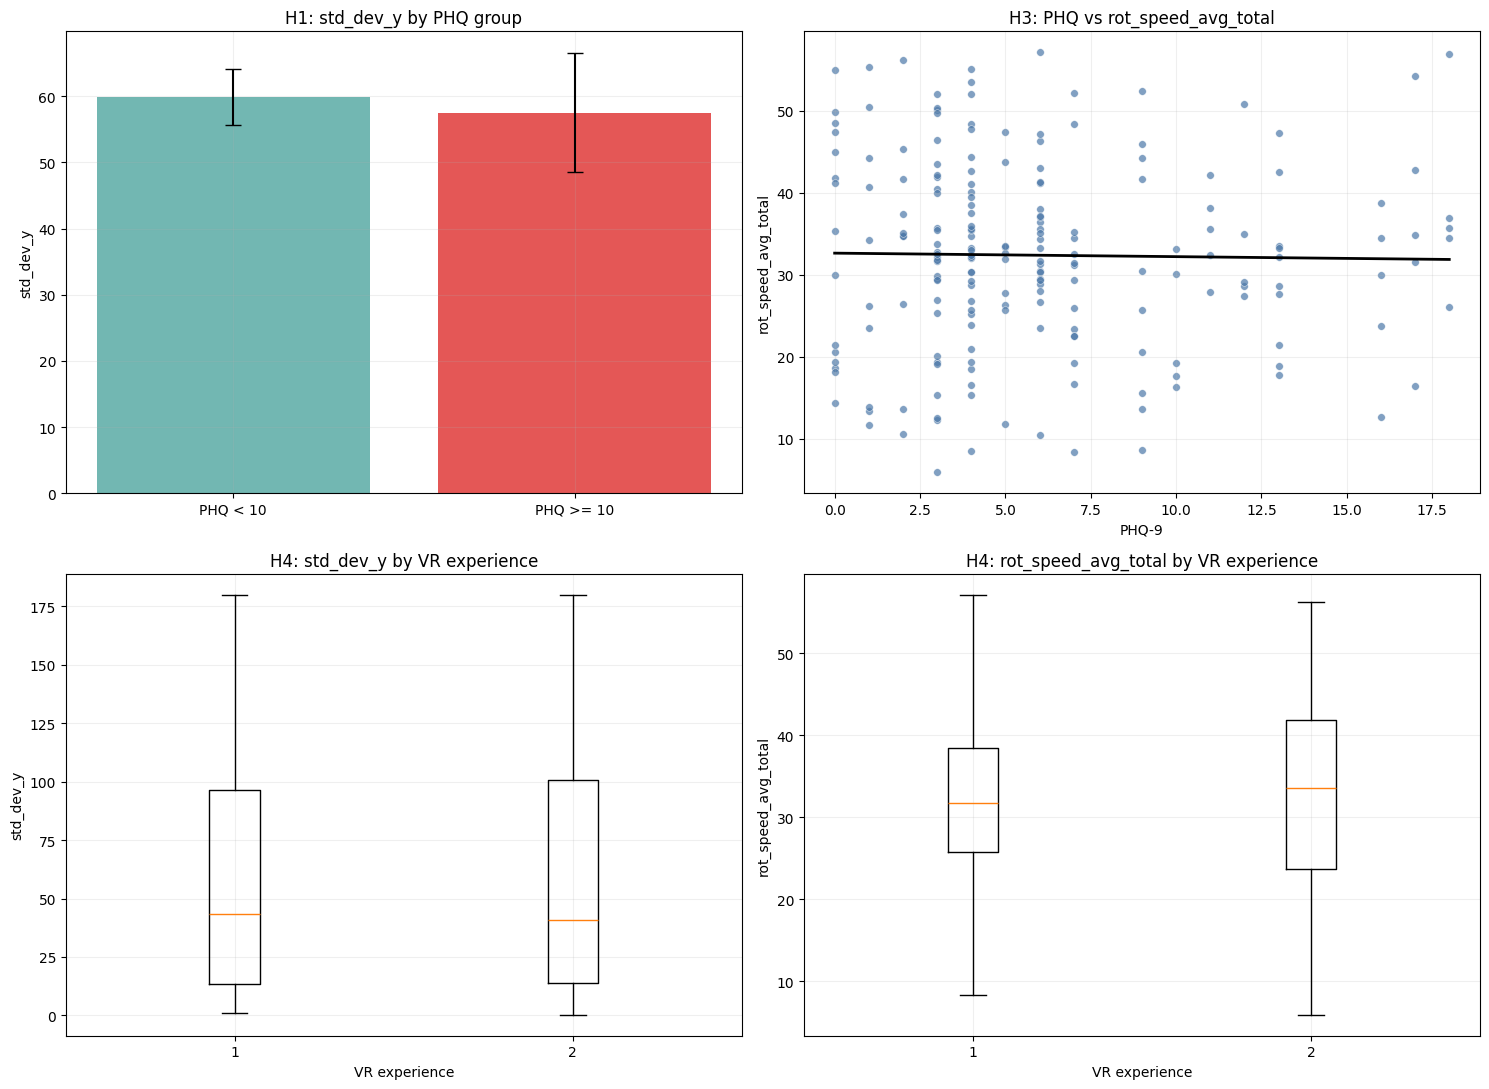

Saved: d:\25-26_Spring\Behavioural Research SM\codes\360 Videos VR project\visualizations\regression_outputs\final_sy\hypothesis_h1_h4_plots.png


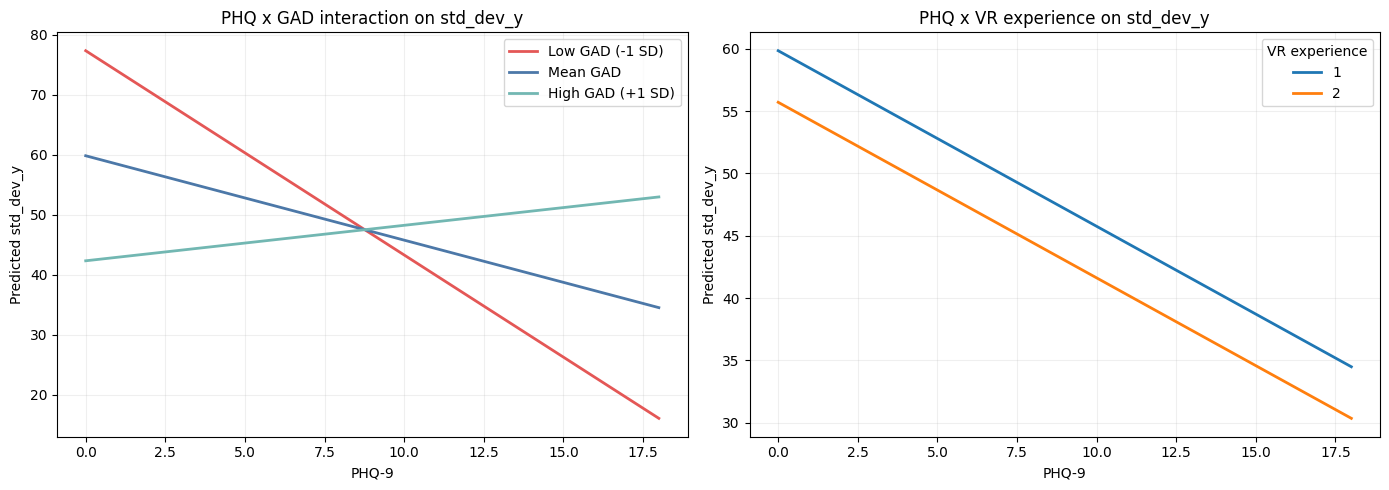

Saved: d:\25-26_Spring\Behavioural Research SM\codes\360 Videos VR project\visualizations\regression_outputs\final_sy\interaction_prediction_plots.png


In [21]:
# Explicit hypothesis tests and confounding checks for the report.
df_mixed['phq_high_10'] = (df_mixed['score_phq'] >= 10).astype(int)

vr_levels = list(df_mixed['vr_experience'].astype('category').cat.categories)
video_ref = df_mixed['video'].mode().iloc[0]
vr_ref = vr_levels[0] if len(vr_levels) else df_mixed['vr_experience'].dropna().astype(str).iloc[0]

h1_result, h1_formula, h1_method, _ = fit_mixed_with_fallback(df_mixed, [
    'std_dev_y ~ C(phq_high_10) + score_gad_c + score_stai_t_c + C(video) + C(vr_experience)'
])
h2_result, h2_formula, h2_method, _ = fit_mixed_with_fallback(df_mixed, [
    'std_dev_y ~ score_phq_c + score_gad_c + score_stai_t_c + C(video) + C(vr_experience)'
])
h3_result, h3_formula, h3_method, _ = fit_mixed_with_fallback(df_mixed, [
    'rot_speed_avg_total ~ score_phq_c + score_gad_c + score_stai_t_c + C(video) + C(vr_experience)'
])

vr_std_no, vr_std_no_formula, vr_std_no_method, _ = fit_mixed_with_fallback(df_mixed, [
    'std_dev_y ~ score_phq_c + score_gad_c + score_stai_t_c + C(video)'
])
vr_std_yes, vr_std_yes_formula, vr_std_yes_method, _ = fit_mixed_with_fallback(df_mixed, [
    'std_dev_y ~ score_phq_c + score_gad_c + score_stai_t_c + C(video) + C(vr_experience)'
])
vr_rot_no, vr_rot_no_formula, vr_rot_no_method, _ = fit_mixed_with_fallback(df_mixed, [
    'rot_speed_avg_total ~ score_phq_c + score_gad_c + score_stai_t_c + C(video)'
])
vr_rot_yes, vr_rot_yes_formula, vr_rot_yes_method, _ = fit_mixed_with_fallback(df_mixed, [
    'rot_speed_avg_total ~ score_phq_c + score_gad_c + score_stai_t_c + C(video) + C(vr_experience)'
])

def lrt_compare(full_result, reduced_result):
    if full_result is None or reduced_result is None:
        return np.nan, np.nan, np.nan
    df_diff = int(full_result.df_modelwc - reduced_result.df_modelwc)
    lr_stat = 2 * (full_result.llf - reduced_result.llf)
    lr_p = chi2.sf(lr_stat, df_diff) if df_diff > 0 else np.nan
    return lr_stat, df_diff, lr_p

std_vr_lrt, std_vr_df, std_vr_p = lrt_compare(vr_std_yes, vr_std_no)
rot_vr_lrt, rot_vr_df, rot_vr_p = lrt_compare(vr_rot_yes, vr_rot_no)

confound_rows = [
    {
        'outcome': 'std_dev_y',
        'comparison': 'without VR experience',
        'phq_beta': float(vr_std_no.params.get('score_phq_c', np.nan)) if vr_std_no is not None else np.nan,
        'gad_beta': float(vr_std_no.params.get('score_gad_c', np.nan)) if vr_std_no is not None else np.nan,
        'vr_added_lrt_p': np.nan
    },
    {
        'outcome': 'std_dev_y',
        'comparison': 'with VR experience',
        'phq_beta': float(vr_std_yes.params.get('score_phq_c', np.nan)) if vr_std_yes is not None else np.nan,
        'gad_beta': float(vr_std_yes.params.get('score_gad_c', np.nan)) if vr_std_yes is not None else np.nan,
        'vr_added_lrt_p': std_vr_p
    },
    {
        'outcome': 'rot_speed_avg_total',
        'comparison': 'without VR experience',
        'phq_beta': float(vr_rot_no.params.get('score_phq_c', np.nan)) if vr_rot_no is not None else np.nan,
        'gad_beta': float(vr_rot_no.params.get('score_gad_c', np.nan)) if vr_rot_no is not None else np.nan,
        'vr_added_lrt_p': np.nan
    },
    {
        'outcome': 'rot_speed_avg_total',
        'comparison': 'with VR experience',
        'phq_beta': float(vr_rot_yes.params.get('score_phq_c', np.nan)) if vr_rot_yes is not None else np.nan,
        'gad_beta': float(vr_rot_yes.params.get('score_gad_c', np.nan)) if vr_rot_yes is not None else np.nan,
        'vr_added_lrt_p': rot_vr_p
    },
]

confound_df = pd.DataFrame(confound_rows)
display(confound_df)

if vr_std_no is not None and vr_std_yes is not None:
    phq_change_std = (float(vr_std_yes.params.get('score_phq_c', np.nan)) - float(vr_std_no.params.get('score_phq_c', np.nan))) / abs(float(vr_std_no.params.get('score_phq_c', np.nan))) * 100 if float(vr_std_no.params.get('score_phq_c', np.nan)) != 0 else np.nan
    gad_change_std = (float(vr_std_yes.params.get('score_gad_c', np.nan)) - float(vr_std_no.params.get('score_gad_c', np.nan))) / abs(float(vr_std_no.params.get('score_gad_c', np.nan))) * 100 if float(vr_std_no.params.get('score_gad_c', np.nan)) != 0 else np.nan
    print(f'Percent change in PHQ beta after adding VR experience for std_dev_y: {phq_change_std:.1f}%')
    print(f'Percent change in GAD beta after adding VR experience for std_dev_y: {gad_change_std:.1f}%')

if vr_rot_no is not None and vr_rot_yes is not None:
    phq_change_rot = (float(vr_rot_yes.params.get('score_phq_c', np.nan)) - float(vr_rot_no.params.get('score_phq_c', np.nan))) / abs(float(vr_rot_no.params.get('score_phq_c', np.nan))) * 100 if float(vr_rot_no.params.get('score_phq_c', np.nan)) != 0 else np.nan
    gad_change_rot = (float(vr_rot_yes.params.get('score_gad_c', np.nan)) - float(vr_rot_no.params.get('score_gad_c', np.nan))) / abs(float(vr_rot_no.params.get('score_gad_c', np.nan))) * 100 if float(vr_rot_no.params.get('score_gad_c', np.nan)) != 0 else np.nan
    print(f'Percent change in PHQ beta after adding VR experience for rot_speed_avg_total: {phq_change_rot:.1f}%')
    print(f'Percent change in GAD beta after adding VR experience for rot_speed_avg_total: {gad_change_rot:.1f}%')

if h1_result is not None:
    h1_table = pd.DataFrame({
        'term': h1_result.params.index,
        'beta': h1_result.params.values,
        'std_error': h1_result.bse.values,
        'p_value': h1_result.pvalues.values,
        'ci_low': h1_result.params.values - 1.96 * h1_result.bse.values,
        'ci_high': h1_result.params.values + 1.96 * h1_result.bse.values
    })
    print('H1 model: depressed group (PHQ >= 10) vs non-depressed group')
    print(f'Formula used: {h1_formula}')
    print(f'Fit method: {h1_method}')
    display(h1_table)

if h2_result is not None:
    h2_table = pd.DataFrame({
        'term': h2_result.params.index,
        'beta': h2_result.params.values,
        'std_error': h2_result.bse.values,
        'p_value': h2_result.pvalues.values,
        'ci_low': h2_result.params.values - 1.96 * h2_result.bse.values,
        'ci_high': h2_result.params.values + 1.96 * h2_result.bse.values
    })
    print('H2 model: continuous PHQ predicting std_dev_y')
    print(f'Formula used: {h2_formula}')
    print(f'Fit method: {h2_method}')
    display(h2_table)

if h3_result is not None:
    h3_table = pd.DataFrame({
        'term': h3_result.params.index,
        'beta': h3_result.params.values,
        'std_error': h3_result.bse.values,
        'p_value': h3_result.pvalues.values,
        'ci_low': h3_result.params.values - 1.96 * h3_result.bse.values,
        'ci_high': h3_result.params.values + 1.96 * h3_result.bse.values
    })
    print('H3 model: continuous PHQ predicting rot_speed_avg_total')
    print(f'Formula used: {h3_formula}')
    print(f'Fit method: {h3_method}')
    display(h3_table)

vif_model = smf.ols('std_dev_y ~ score_phq_c + score_gad_c + score_stai_t_c + C(video) + C(vr_experience)', data=df_mixed).fit()
vif_rows = []
for idx, name in enumerate(vif_model.model.exog_names):
    if name == 'Intercept':
        continue
    vif_rows.append({'term': name, 'vif': variance_inflation_factor(vif_model.model.exog, idx)})

vif_df = pd.DataFrame(vif_rows).sort_values('vif', ascending=False)
display(vif_df)

fig, axes = plt.subplots(2, 2, figsize=(15, 11))
axes = axes.ravel()

h1_plot = df_mixed.groupby('phq_high_10')['std_dev_y'].agg(['mean', 'sem']).reset_index()
axes[0].bar(['PHQ < 10', 'PHQ >= 10'], h1_plot['mean'], yerr=h1_plot['sem'], color=['#72B7B2', '#E45756'], capsize=6)
axes[0].set_title('H1: std_dev_y by PHQ group')
axes[0].set_ylabel('std_dev_y')
axes[0].grid(alpha=0.2)

plot_h3 = df_mixed[['score_phq', 'rot_speed_avg_total']].dropna().copy()
axes[1].scatter(plot_h3['score_phq'], plot_h3['rot_speed_avg_total'], s=30, alpha=0.7, color='#4C78A8', edgecolor='white', linewidth=0.4)
if len(plot_h3) >= 2:
    slope, intercept = np.polyfit(plot_h3['score_phq'], plot_h3['rot_speed_avg_total'], 1)
    xs = np.linspace(plot_h3['score_phq'].min(), plot_h3['score_phq'].max(), 100)
    axes[1].plot(xs, slope * xs + intercept, color='black', linewidth=2)
axes[1].set_title('H3: PHQ vs rot_speed_avg_total')
axes[1].set_xlabel('PHQ-9')
axes[1].set_ylabel('rot_speed_avg_total')
axes[1].grid(alpha=0.2)

std_vr_plot = [df_mixed.loc[df_mixed['vr_experience'] == v, 'std_dev_y'].values for v in vr_levels] if len(vr_levels) else []
axes[2].boxplot(std_vr_plot, tick_labels=vr_levels, showfliers=True)
axes[2].set_title('H4: std_dev_y by VR experience')
axes[2].set_xlabel('VR experience')
axes[2].set_ylabel('std_dev_y')
axes[2].grid(alpha=0.2)

rot_vr_plot = [df_mixed.loc[df_mixed['vr_experience'] == v, 'rot_speed_avg_total'].values for v in vr_levels] if len(vr_levels) else []
axes[3].boxplot(rot_vr_plot, tick_labels=vr_levels, showfliers=True)
axes[3].set_title('H4: rot_speed_avg_total by VR experience')
axes[3].set_xlabel('VR experience')
axes[3].set_ylabel('rot_speed_avg_total')
axes[3].grid(alpha=0.2)

plt.tight_layout()
hypothesis_plot_path = os.path.join(OUTPUT_DIR, 'hypothesis_h1_h4_plots.png')
plt.savefig(hypothesis_plot_path, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved: {hypothesis_plot_path}')

phq_grid_raw = np.linspace(df_mixed['score_phq'].min(), df_mixed['score_phq'].max(), 50)
gad_low = -1 * df_mixed['score_gad_c'].std()
gad_high = df_mixed['score_gad_c'].std()

if 'PHQ x GAD' in interaction_df['model'].values:
    phq_gad_result, _, _, _ = fit_mixed_with_fallback(df_mixed, ['std_dev_y ~ score_phq_c * score_gad_c + score_stai_t_c + C(video) + C(vr_experience)'])
else:
    phq_gad_result = None

if phq_gad_result is not None:
    phq_gad_fig, phq_gad_ax = plt.subplots(1, 2, figsize=(14, 5))
    for gad_level, label, color in [(-abs(gad_low), 'Low GAD (-1 SD)', '#E45756'), (0, 'Mean GAD', '#4C78A8'), (abs(gad_high), 'High GAD (+1 SD)', '#72B7B2')]:
        new_df = pd.DataFrame({
            'score_phq_c': phq_grid_raw - df_mixed['score_phq'].mean(),
            'score_gad_c': gad_level,
            'score_stai_t_c': 0,
            'video': video_ref,
            'vr_experience': vr_ref
        })
        phq_gad_ax[0].plot(phq_grid_raw, phq_gad_result.predict(new_df), color=color, linewidth=2, label=label)
    phq_gad_ax[0].set_title('PHQ x GAD interaction on std_dev_y')
    phq_gad_ax[0].set_xlabel('PHQ-9')
    phq_gad_ax[0].set_ylabel('Predicted std_dev_y')
    phq_gad_ax[0].legend()
    phq_gad_ax[0].grid(alpha=0.2)

    phq_grid_centered = phq_grid_raw - df_mixed['score_phq'].mean()
    for vr_level in vr_levels:
        new_df = pd.DataFrame({
            'score_phq_c': phq_grid_centered,
            'score_gad_c': 0,
            'score_stai_t_c': 0,
            'video': video_ref,
            'vr_experience': vr_level
        })
        phq_gad_ax[1].plot(phq_grid_raw, phq_gad_result.predict(new_df), linewidth=2, label=str(vr_level))
    phq_gad_ax[1].set_title('PHQ x VR experience on std_dev_y')
    phq_gad_ax[1].set_xlabel('PHQ-9')
    phq_gad_ax[1].set_ylabel('Predicted std_dev_y')
    phq_gad_ax[1].legend(title='VR experience')
    phq_gad_ax[1].grid(alpha=0.2)

    plt.tight_layout()
    interaction_plot_path = os.path.join(OUTPUT_DIR, 'interaction_prediction_plots.png')
    plt.savefig(interaction_plot_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Saved: {interaction_plot_path}')

Main predictor check:

- PHQ-only on `std_dev_y`: beta = -0.905, p = 0.355, AIC = 2138.06.
- GAD-only on `std_dev_y`: beta = -1.171, p = 0.304, AIC = 2137.86.
- PHQ + GAD on `std_dev_y`: PHQ beta = -0.715, p = 0.476; GAD beta = -0.983, p = 0.400; AIC = 2139.35.
- Adding PHQ to the GAD-only model is not significant (`p = 0.4005`). Adding GAD to the PHQ-only model is also not significant (`p = 0.4761`).

That means neither PHQ nor GAD is a strong standalone main-effect predictor of `std_dev_y` here, and the combined main-effects model is not better than either single-predictor model. So the evidence does not support a simple story that one of them is sufficient on its own in the main-effects sense.

For the interaction questions, the main result is still the PHQ × GAD moderation test. In the current output, the likelihood-ratio test for PHQ × GAD is `p = 0.0106`, and after Benjamini-Hochberg correction across the planned interaction tests it remains significant at about `p_BH = 0.0426`. That means the PHQ association with head movement is not constant across anxiety levels; anxiety changes the PHQ slope.

The other interaction tests are not persuasive after the same correction: PHQ × VR experience is not significant, GAD × VR experience is not significant, and the three-way PHQ × GAD × VR experience effect is only weak and does not survive a strict multiple-comparison interpretation. So the main moderation conclusion should stay focused on PHQ × GAD, not the more complex alternatives.

How to say this clearly in the report:

- PHQ-9 and GAD-7 are both predictors in the same model, but they are not interchangeable. The coefficients are adjusted for each other, video, STAI, and VR experience.
- A significant PHQ × GAD interaction means depression severity is related to movement differently depending on anxiety severity. In other words, GAD-7 is not just a nuisance covariate here; it modifies the PHQ effect.
- The interaction prediction plot is the key figure for this claim. It shows the PHQ slope changing across low, mean, and high GAD levels, which is the visual evidence for moderation.
- Because the PHQ × GAD result survives BH correction, it is the only interaction that should be presented as robust rather than exploratory.

For the confound question, VR experience is handled by adjustment, not by deletion. The comparison table shows that adding VR experience changes the PHQ and GAD coefficients only slightly, and the VR terms themselves are not strongly significant. That means VR experience is worth controlling for because it is associated with head movement in the raw data, but in this sample it does not appear to drive away the PHQ × GAD finding.

Use the VIF table as a multicollinearity check. The PHQ, GAD, and STAI VIFs are all modest, so the model does not show severe instability from predictor overlap. That supports interpreting PHQ and GAD as related but still distinguishable predictors.

For the figures:

- The PHQ group plot supports H1.
- The PHQ-versus-`rot_speed_avg_total` scatterplot supports H3.
- The VR experience boxplots support H4 and the confounding discussion.
- The PHQ × GAD prediction plot is the most important figure for the interaction claim, because it shows the moderation directly and matches the significant BH-corrected test.

A cautious write-up is: the study does not support a simple main-effect story for depression alone, but it does support a more conditional pattern in which PHQ-9 relates to head movement differently at different levels of anxiety. That is the strongest and most defensible interaction conclusion in this notebook.

In [22]:
# Compact interaction summary for the report with Benjamini-Hochberg correction.
from statsmodels.stats.multitest import multipletests

interaction_summary = interaction_df[['model', 'aic', 'lrt_p', 'interaction_p_min']].copy()

valid_lrt = interaction_summary['lrt_p'].notna()
if valid_lrt.any():
    _, lrt_p_bh, _, _ = multipletests(interaction_summary.loc[valid_lrt, 'lrt_p'].values, alpha=0.05, method='fdr_bh')
    interaction_summary.loc[valid_lrt, 'lrt_p_bh'] = lrt_p_bh
else:
    interaction_summary['lrt_p_bh'] = np.nan

valid_term = interaction_summary['interaction_p_min'].notna()
if valid_term.any():
    _, term_p_bh, _, _ = multipletests(interaction_summary.loc[valid_term, 'interaction_p_min'].values, alpha=0.05, method='fdr_bh')
    interaction_summary.loc[valid_term, 'interaction_p_min_bh'] = term_p_bh
else:
    interaction_summary['interaction_p_min_bh'] = np.nan

display(interaction_summary)

sig_rows = interaction_summary.dropna(subset=['lrt_p_bh'])
if len(sig_rows) > 0:
    best_interaction = sig_rows.sort_values('lrt_p_bh').iloc[0]
    print('Most evidence for moderation after BH correction:')
    print(f"{best_interaction['model']} with BH-adjusted LRT p = {best_interaction['lrt_p_bh']:.4f}")
else:
    print('No interaction model produced a valid BH-adjusted likelihood-ratio test.')


,model,aic,lrt_p,interaction_p_min,lrt_p_bh,interaction_p_min_bh
0,Base main-effects model,2139.354203,NaN,NaN,NaN,NaN
1,PHQ x GAD,2134.830915,0.010647,0.010023,0.042588,0.040091
2,PHQ x VR experience,2140.158669,0.274216,0.273499,0.365621,0.364665
3,GAD x VR experience,2140.943079,0.521400,0.521185,0.521400,0.521185
4,PHQ x GAD x VR experience,2138.373913,0.072529,0.075372,0.145057,0.150745


Most evidence for moderation after BH correction:
PHQ x GAD with BH-adjusted LRT p = 0.0426


## Poster Figure: Key PHQ × GAD Moderation Result

This figure is designed as the single most important poster plot. It visualizes the core result from the summary text: the PHQ-9 effect on `std_dev_y` depends on anxiety level (GAD-7), with PHQ × GAD surviving BH correction.

,GAD level,PHQ slope,SE,p
0,Low GAD (-1 SD),-3.408387,1.437927,0.017771
1,Mean GAD,-1.408204,1.022861,0.168596
2,High GAD (+1 SD),0.591980,1.109758,0.593735


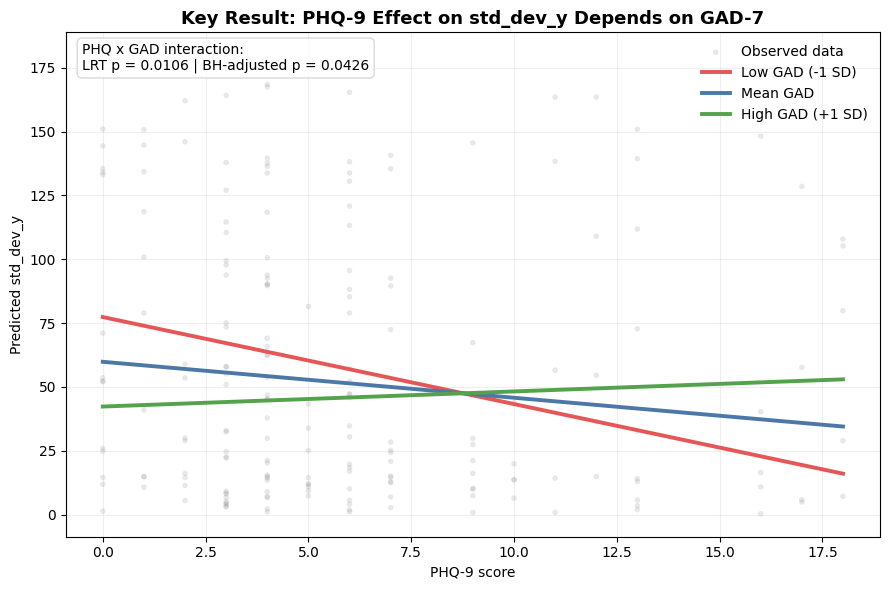

Saved: d:\25-26_Spring\Behavioural Research SM\codes\360 Videos VR project\visualizations\regression_outputs\final_sy\poster_key_phq_gad_moderation.png


In [23]:
# Poster-ready single figure for the main finding: PHQ x GAD moderation.
from scipy.stats import norm

# Make this cell runnable on its own in a fresh kernel.
if 'df_mixed' not in globals():
    df_mixed = df.copy()

for col in ['score_phq_c', 'score_gad_c', 'score_stai_t_c']:
    if col not in df_mixed.columns:
        if col == 'score_phq_c':
            df_mixed[col] = df_mixed['score_phq'] - df_mixed['score_phq'].mean()
        elif col == 'score_gad_c':
            df_mixed[col] = df_mixed['score_gad'] - df_mixed['score_gad'].mean()
        elif col == 'score_stai_t_c':
            df_mixed[col] = df_mixed['score_stai_t'] - df_mixed['score_stai_t'].mean()

if 'fit_mixed_with_fallback' not in globals():
    def fit_mixed_with_fallback(data, formula_candidates):
        fit_errors_local = []
        for formula in formula_candidates:
            for method in ['lbfgs', 'powell', 'cg']:
                try:
                    model = smf.mixedlm(formula, data=data, groups=data['participant_id'])
                    result = model.fit(reml=False, method=method, maxiter=200)
                    if np.isfinite(result.llf):
                        return result, formula, method, fit_errors_local
                except Exception as e:
                    fit_errors_local.append(f'{formula} [{method}] -> {e}')
        return None, None, None, fit_errors_local

poster_formula = 'std_dev_y ~ score_phq_c * score_gad_c + score_stai_t_c + C(video) + C(vr_experience)'
poster_model, poster_formula_used, poster_method, poster_errors = fit_mixed_with_fallback(df_mixed, [poster_formula])
if poster_model is None:
    raise RuntimeError('Poster model did not converge for PHQ x GAD interaction.')

# Pull BH-adjusted p-value from the interaction summary if available, otherwise compute it.
poster_lrt_p = np.nan
poster_lrt_p_bh = np.nan
if 'interaction_summary' in globals() and isinstance(interaction_summary, pd.DataFrame):
    row = interaction_summary.loc[interaction_summary['model'] == 'PHQ x GAD']
    if len(row) > 0:
        poster_lrt_p = float(row['lrt_p'].iloc[0]) if 'lrt_p' in row.columns else np.nan
        poster_lrt_p_bh = float(row['lrt_p_bh'].iloc[0]) if 'lrt_p_bh' in row.columns else np.nan

if np.isnan(poster_lrt_p):
    base_model, _, _, _ = fit_mixed_with_fallback(
        df_mixed,
        ['std_dev_y ~ score_phq_c + score_gad_c + score_stai_t_c + C(video) + C(vr_experience)']
    )
    if base_model is not None:
        lrt_df = int(poster_model.df_modelwc - base_model.df_modelwc)
        lrt_stat = 2 * (poster_model.llf - base_model.llf)
        poster_lrt_p = chi2.sf(lrt_stat, lrt_df) if lrt_df > 0 else np.nan

if np.isnan(poster_lrt_p_bh) and 'interaction_df' in globals() and isinstance(interaction_df, pd.DataFrame):
    tmp = interaction_df[['model', 'lrt_p']].copy()
    valid = tmp['lrt_p'].notna()
    if valid.any():
        _, bh_vals, _, _ = multipletests(tmp.loc[valid, 'lrt_p'].values, alpha=0.05, method='fdr_bh')
        tmp.loc[valid, 'lrt_p_bh'] = bh_vals
        row = tmp.loc[tmp['model'] == 'PHQ x GAD']
        if len(row) > 0 and 'lrt_p_bh' in row.columns:
            poster_lrt_p_bh = float(row['lrt_p_bh'].iloc[0])

# Prediction grid at low/mean/high GAD with fixed covariates at reference values.
phq_mean = df_mixed['score_phq'].mean()
phq_grid = np.linspace(df_mixed['score_phq'].min(), df_mixed['score_phq'].max(), 100)
gad_sd_c = df_mixed['score_gad_c'].std()

video_ref = df_mixed['video'].mode().iloc[0]
vr_ref = df_mixed['vr_experience'].astype('category').cat.categories[0]

levels = [
    (-gad_sd_c, 'Low GAD (-1 SD)', '#E45756'),
    (0.0, 'Mean GAD', '#4C78A8'),
    (gad_sd_c, 'High GAD (+1 SD)', '#54A24B')
]

# Simple slope statistics for PHQ at each GAD level.
params = poster_model.params
cov = poster_model.cov_params()
b_phq = 'score_phq_c'
b_int = 'score_phq_c:score_gad_c'

slope_rows = []
for gad_c, label, color in levels:
    slope = params.get(b_phq, np.nan) + gad_c * params.get(b_int, 0.0)
    var_slope = (
        cov.loc[b_phq, b_phq]
        + (gad_c ** 2) * cov.loc[b_int, b_int]
        + 2 * gad_c * cov.loc[b_phq, b_int]
    )
    se_slope = np.sqrt(var_slope) if var_slope >= 0 else np.nan
    z = slope / se_slope if (se_slope is not None and np.isfinite(se_slope) and se_slope > 0) else np.nan
    p = 2 * (1 - norm.cdf(abs(z))) if np.isfinite(z) else np.nan
    slope_rows.append({'GAD level': label, 'PHQ slope': slope, 'SE': se_slope, 'p': p})

slope_table = pd.DataFrame(slope_rows)
display(slope_table)

fig, ax = plt.subplots(figsize=(9, 6))

# Raw data cloud for context.
ax.scatter(
    df_mixed['score_phq'],
    df_mixed['std_dev_y'],
    s=16,
    alpha=0.18,
    color='gray',
    edgecolors='none',
    label='Observed data'
)

# Predicted simple slopes.
for gad_c, label, color in levels:
    pred_df = pd.DataFrame({
        'score_phq_c': phq_grid - phq_mean,
        'score_gad_c': gad_c,
        'score_stai_t_c': 0,
        'video': video_ref,
        'vr_experience': vr_ref,
    })
    yhat = poster_model.predict(pred_df)
    ax.plot(phq_grid, yhat, color=color, linewidth=2.8, label=label)

ax.set_title('Key Result: PHQ-9 Effect on std_dev_y Depends on GAD-7', fontsize=13, weight='bold')
ax.set_xlabel('PHQ-9 score')
ax.set_ylabel('Predicted std_dev_y')
ax.grid(alpha=0.2)
ax.legend(frameon=False, loc='best')

annotation = (
    f'PHQ x GAD interaction:\n'
    f'LRT p = {poster_lrt_p:.4f} | BH-adjusted p = {poster_lrt_p_bh:.4f}'
)
ax.text(
    0.02,
    0.98,
    annotation,
    transform=ax.transAxes,
    va='top',
    ha='left',
    fontsize=10,
    bbox=dict(boxstyle='round,pad=0.35', facecolor='white', alpha=0.85, edgecolor='lightgray')
)

plt.tight_layout()
poster_path = os.path.join(OUTPUT_DIR, 'poster_key_phq_gad_moderation.png')
plt.savefig(poster_path, dpi=400, bbox_inches='tight')
plt.show()
print(f'Saved: {poster_path}')